In [ ]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        flattened_images = []
        for i in range(size):
            images.append([0] * rows * cols)
            flattened_images.append([0]*rows*cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            flt_img = img.copy()
            img = img.reshape(28, 28)
            flattened_images[i]            
            images[i][:] = img            
            flattened_images[i][:] = flt_img
            
        return flattened_images, images, labels
            
    def load_data(self):
        x_train_flat, x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test_flat, x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train_flat, x_train, y_train),(x_test_flat, x_test, y_test)        



In [ ]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = '../input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train_flat, x_train, y_train), (x_test_flat, x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [ ]:
x_train_flat[0][28*5:28*6]

In [ ]:
x_train[0]

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:

# Define the model
model = keras.Sequential([
    layers.Input(shape=(784,)),      
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")  # Binary classification
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# View architecture
model.summary()


In [ ]:
type_shi = x_train_flat[:10]
print(type(type_shi[0][0]))
print(type(x_train_flat[0][0]))

In [36]:

print(type(x_train_flat[:10]))
print(type(y_train))

<class 'list'>
<class 'array.array'>


In [39]:
int(y_train[0])

5

In [50]:
np_x_train_flat = np.array(x_train_flat)
int_y_train = np.array([int(i) for i in y_train])
# Example training
# X_train: shape (num_samples, 20)
# y_train: shape (num_samples,)
model.fit(
    np_x_train_flat,
    int_y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8628 - loss: 0.6754 - val_accuracy: 0.9194 - val_loss: 0.3153
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9258 - loss: 0.2687 - val_accuracy: 0.9419 - val_loss: 0.2549
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9454 - loss: 0.1992 - val_accuracy: 0.9472 - val_loss: 0.1921
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9566 - loss: 0.1550 - val_accuracy: 0.9577 - val_loss: 0.1619
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9615 - loss: 0.1334 - val_accuracy: 0.9548 - val_loss: 0.1737
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9670 - loss: 0.1153 - val_accuracy: 0.9637 - val_loss: 0.1341
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9717 - loss: 0.0958 - val_accuracy: 0.9610 - val_loss: 0.1441
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9753 - loss: 0.0868 - 

In [51]:
np_x_test_flat = np.array(x_test_flat)
int_y_test = np.array([int(i) for i in y_test])

test_loss, test_accuracy = model.evaluate(np_x_test_flat, int_y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9700 - loss: 0.1152
Test Loss: 0.1152
Test Accuracy: 0.9700


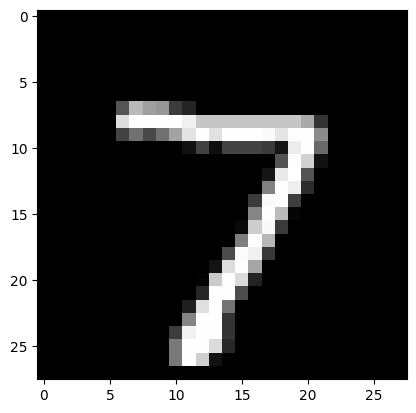

Predicted: 7
Actual: 7


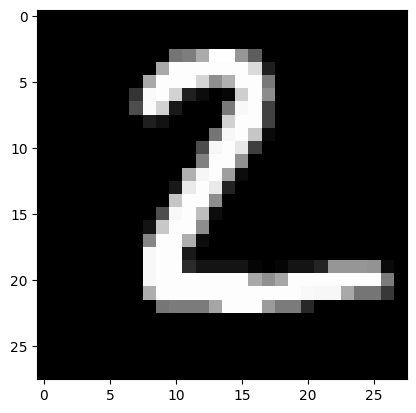

Predicted: 2
Actual: 2


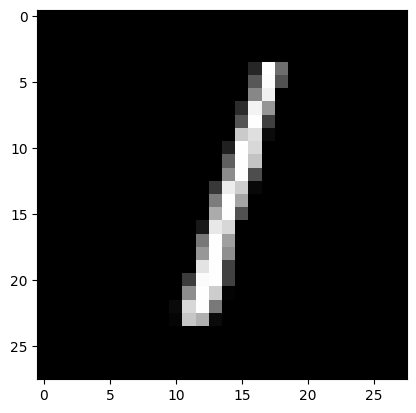

Predicted: 1
Actual: 1


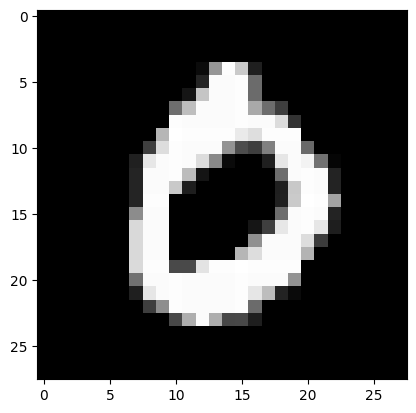

Predicted: 0
Actual: 0


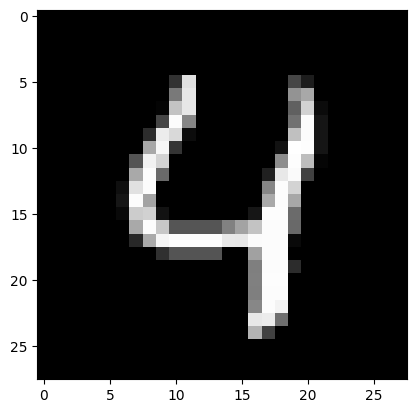

Predicted: 4
Actual: 4


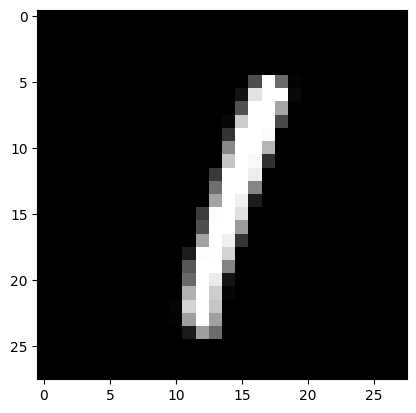

Predicted: 1
Actual: 1


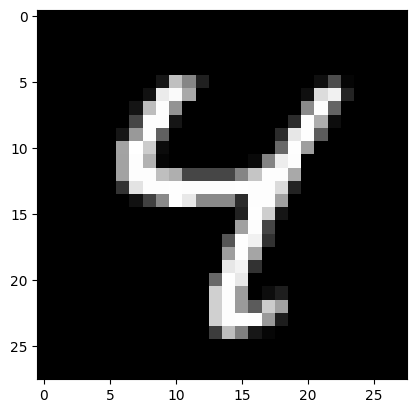

Predicted: 4
Actual: 4


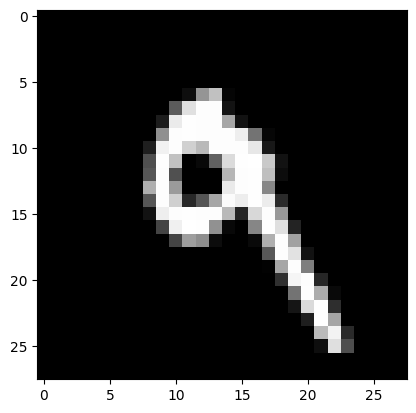

Predicted: 9
Actual: 9


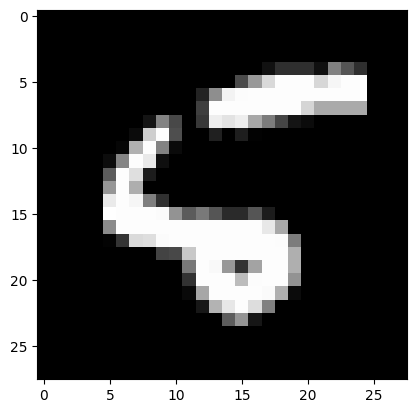

Predicted: 6
Actual: 5


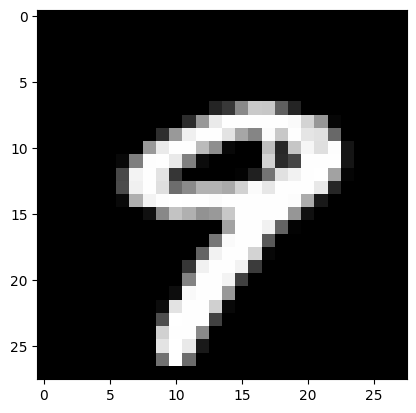

Predicted: 9
Actual: 9


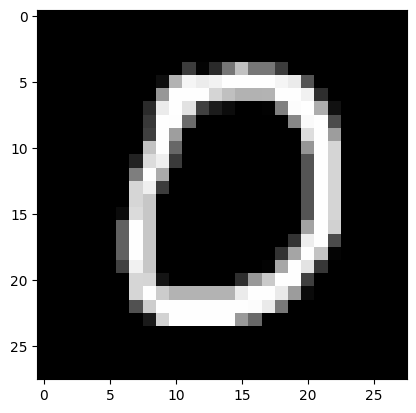

Predicted: 0
Actual: 0


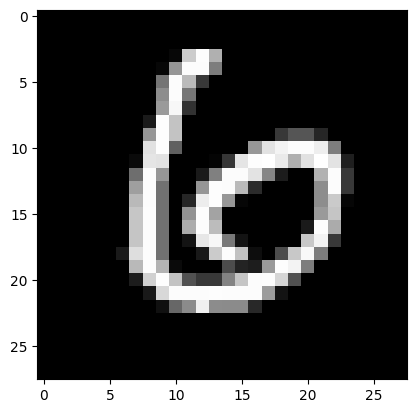

Predicted: 6
Actual: 6


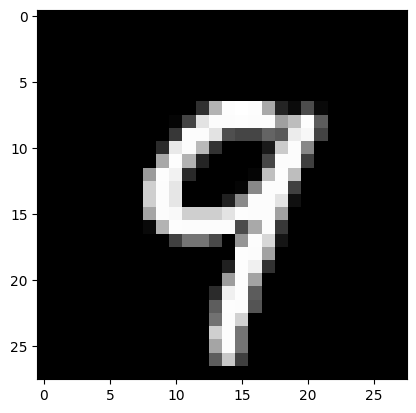

Predicted: 9
Actual: 9


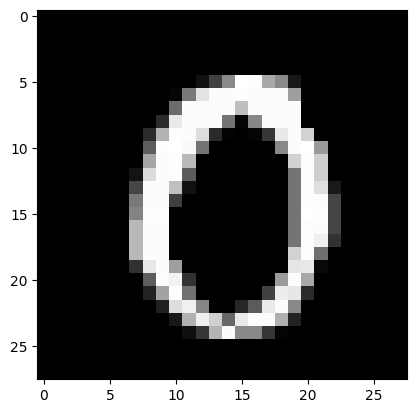

Predicted: 0
Actual: 0


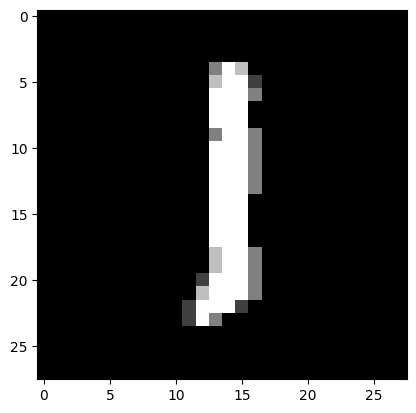

Predicted: 1
Actual: 1


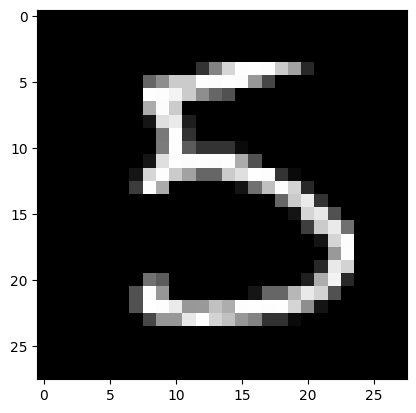

Predicted: 5
Actual: 5


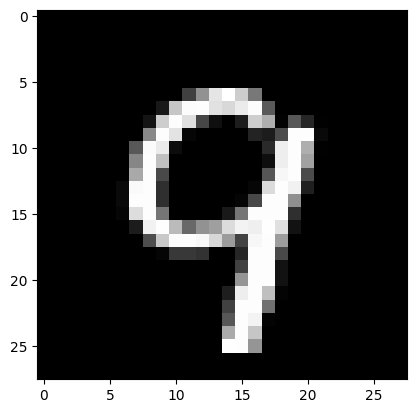

Predicted: 9
Actual: 9


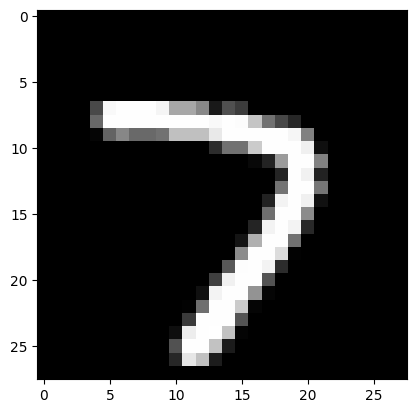

Predicted: 7
Actual: 7


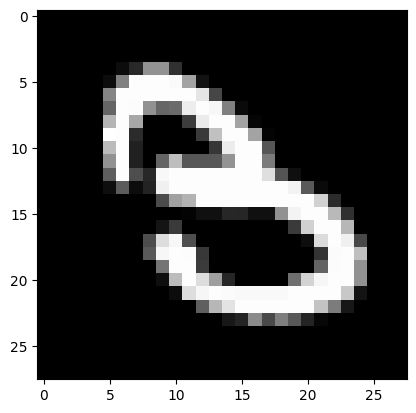

Predicted: 3
Actual: 3


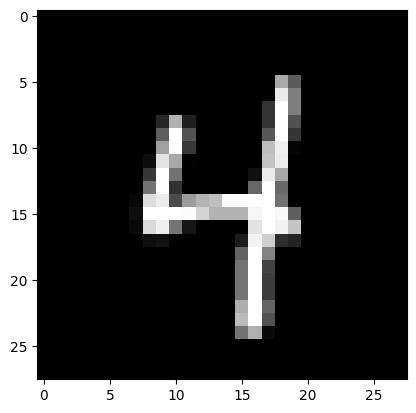

Predicted: 4
Actual: 4


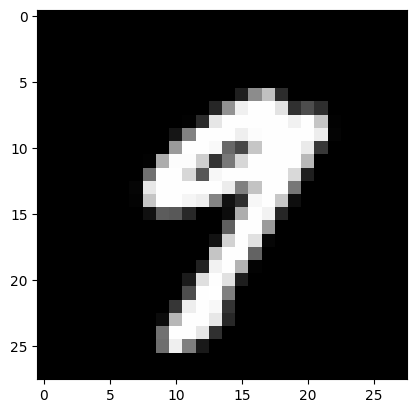

Predicted: 9
Actual: 9


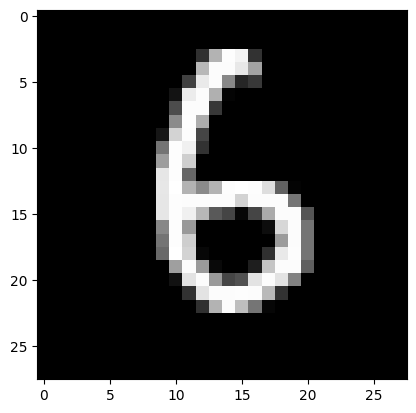

Predicted: 6
Actual: 6


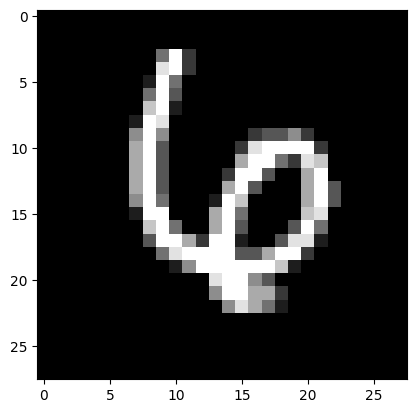

Predicted: 6
Actual: 6


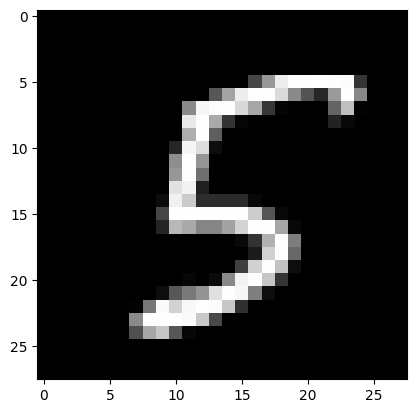

Predicted: 5
Actual: 5


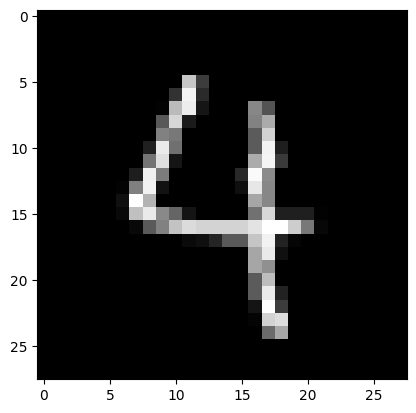

Predicted: 4
Actual: 4


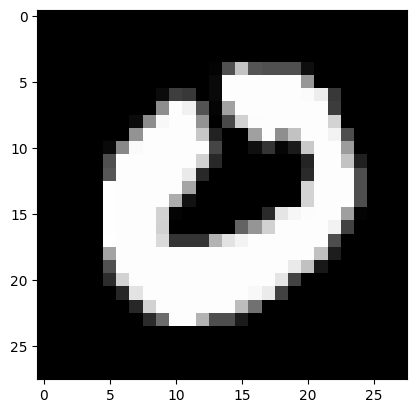

Predicted: 0
Actual: 0


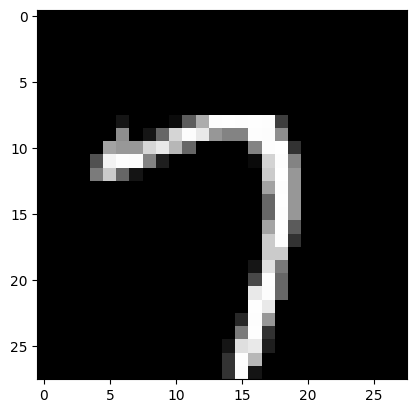

Predicted: 7
Actual: 7


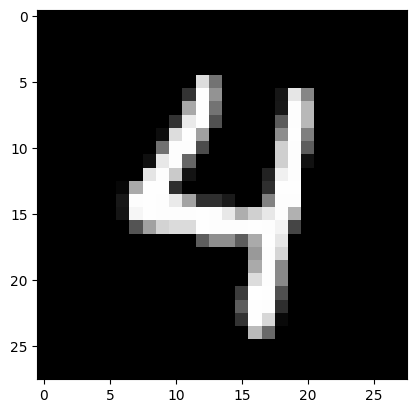

Predicted: 4
Actual: 4


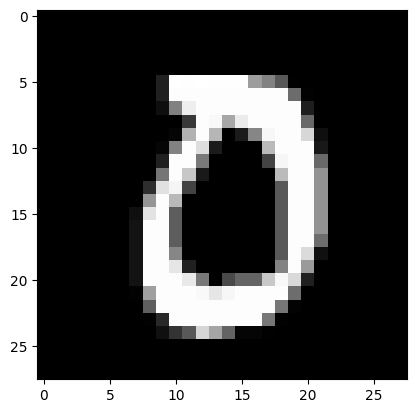

Predicted: 0
Actual: 0


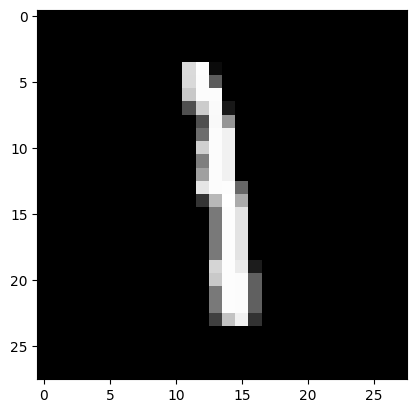

Predicted: 1
Actual: 1


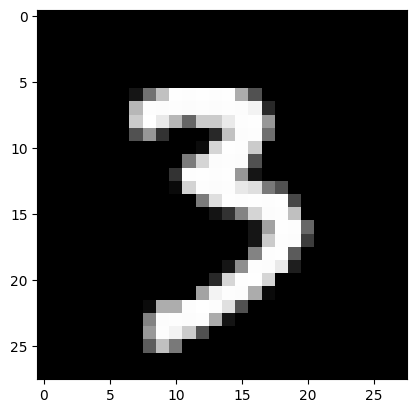

Predicted: 3
Actual: 3


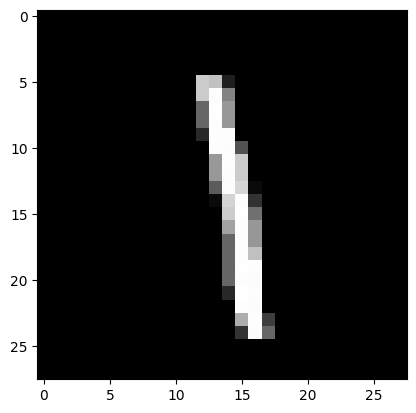

Predicted: 1
Actual: 1


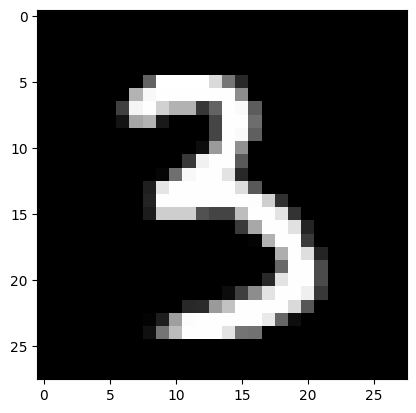

Predicted: 3
Actual: 3


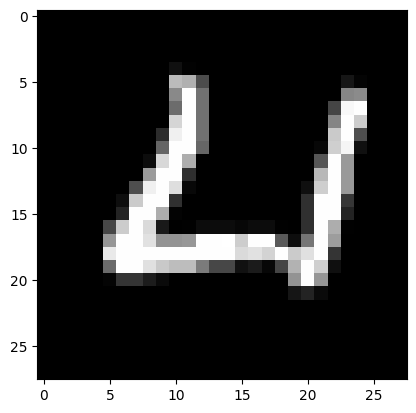

Predicted: 6
Actual: 4


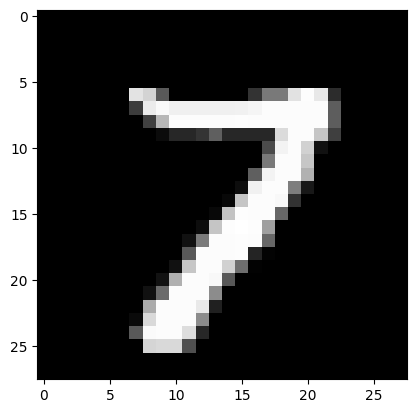

Predicted: 7
Actual: 7


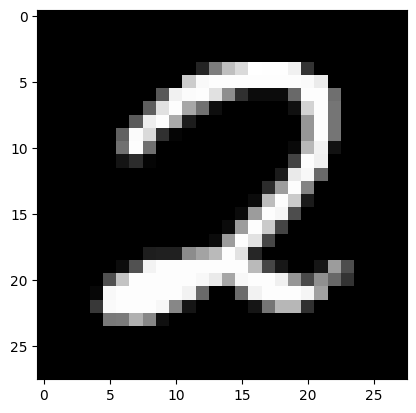

Predicted: 2
Actual: 2


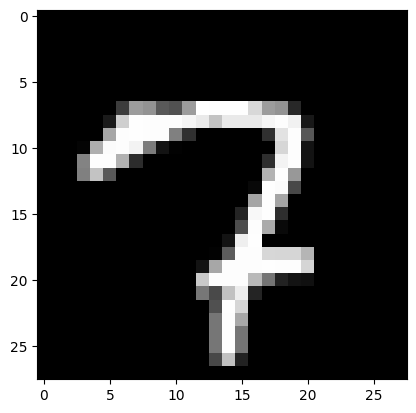

Predicted: 7
Actual: 7


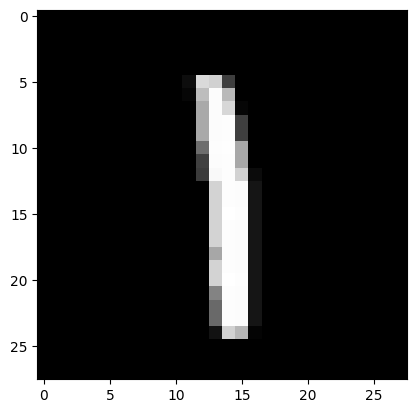

Predicted: 1
Actual: 1


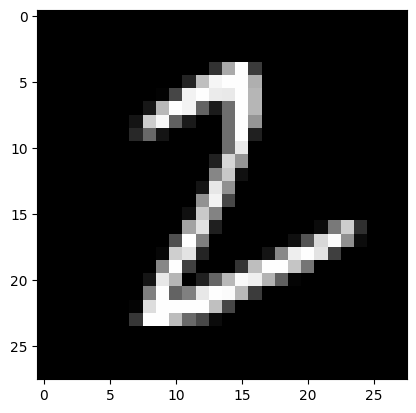

Predicted: 2
Actual: 2


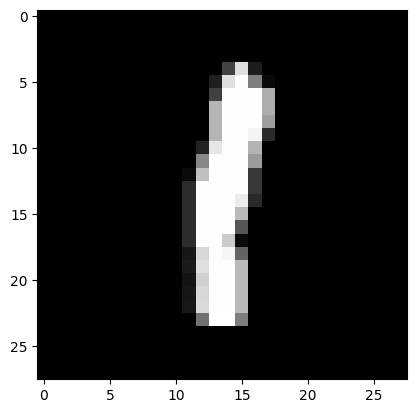

Predicted: 1
Actual: 1


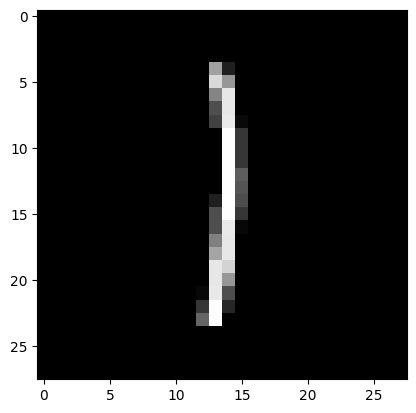

Predicted: 1
Actual: 1


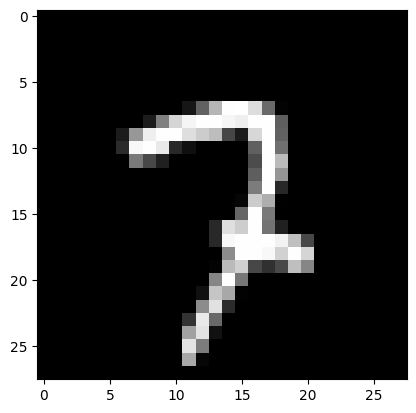

Predicted: 7
Actual: 7


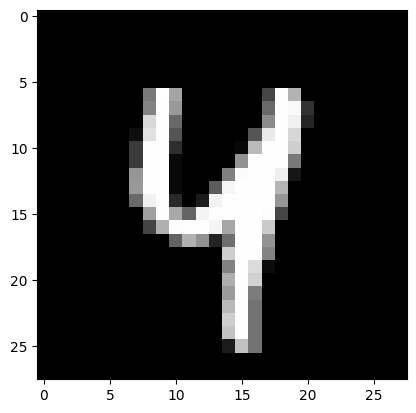

Predicted: 4
Actual: 4


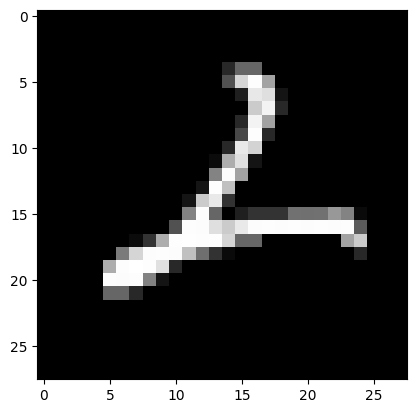

Predicted: 2
Actual: 2


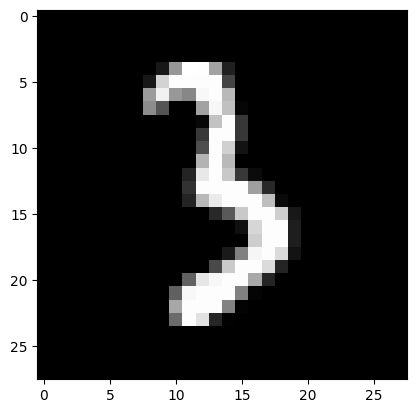

Predicted: 3
Actual: 3


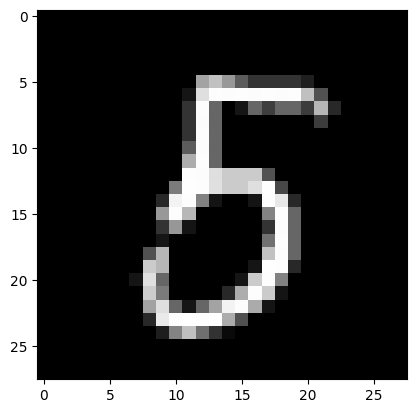

Predicted: 5
Actual: 5


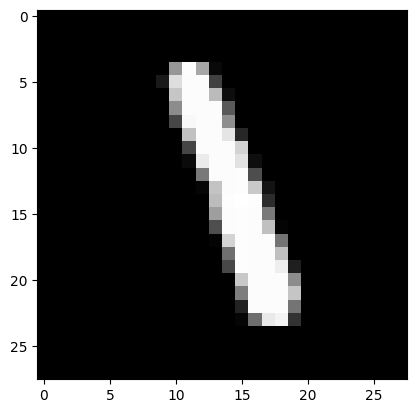

Predicted: 1
Actual: 1


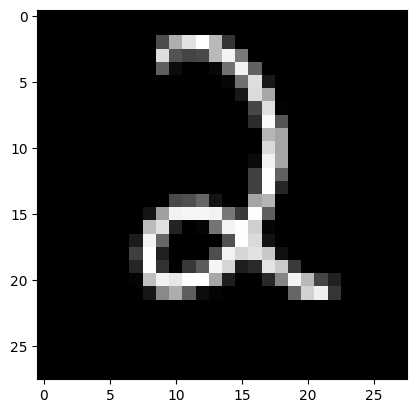

Predicted: 2
Actual: 2


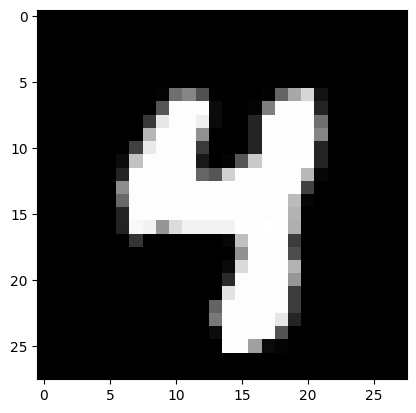

Predicted: 4
Actual: 4


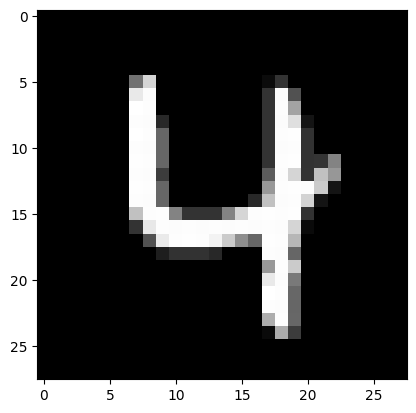

Predicted: 4
Actual: 4


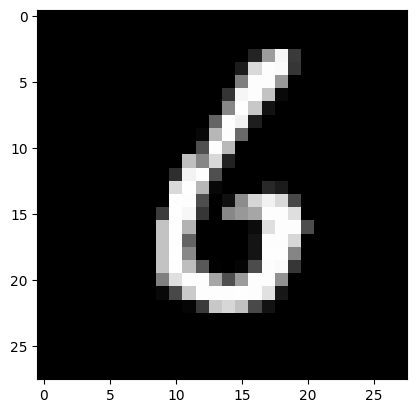

Predicted: 6
Actual: 6


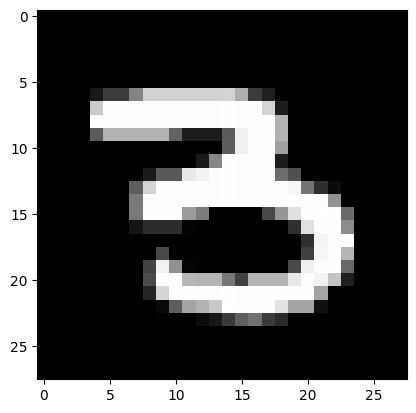

Predicted: 3
Actual: 3


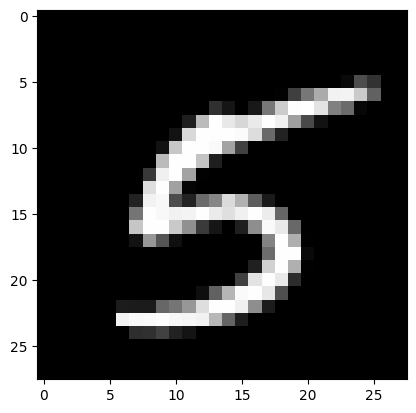

Predicted: 5
Actual: 5


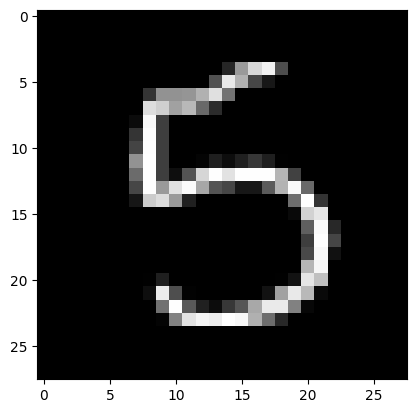

Predicted: 5
Actual: 5


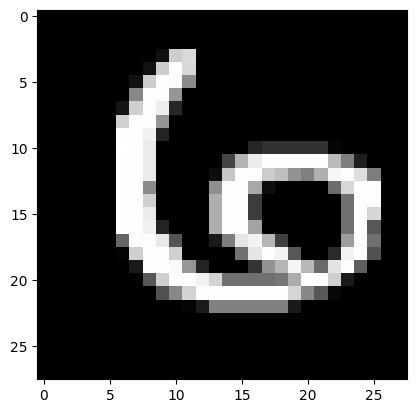

Predicted: 6
Actual: 6


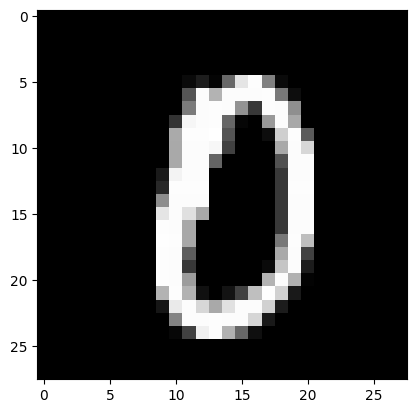

Predicted: 0
Actual: 0


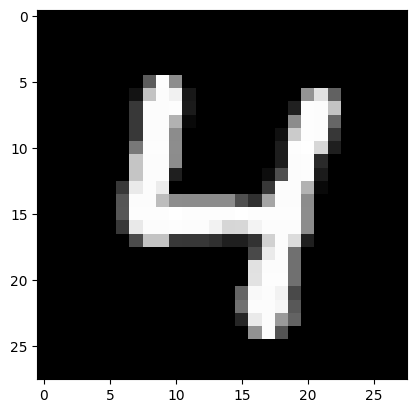

Predicted: 4
Actual: 4


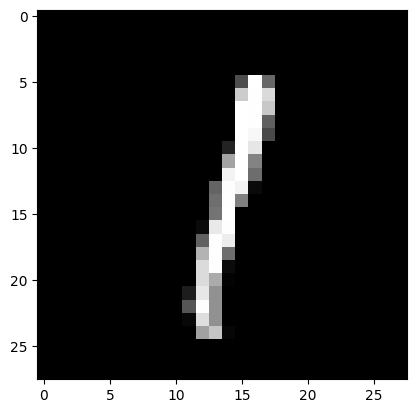

Predicted: 1
Actual: 1


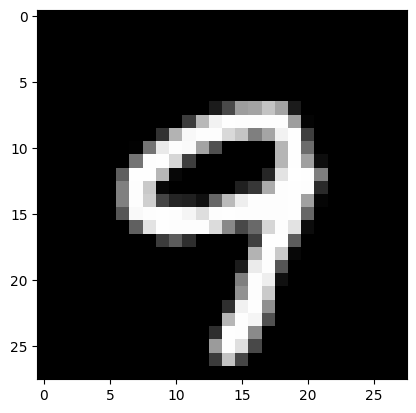

Predicted: 9
Actual: 9


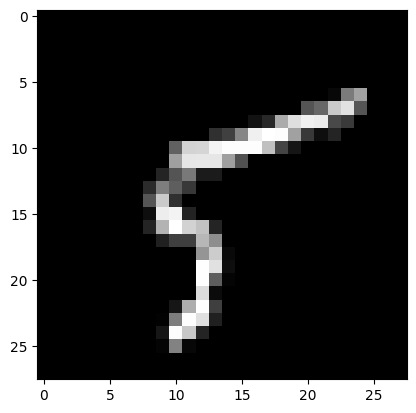

Predicted: 5
Actual: 5


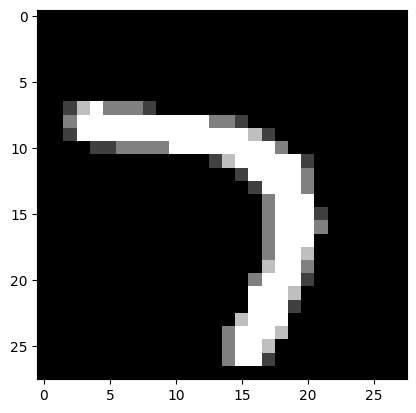

Predicted: 7
Actual: 7


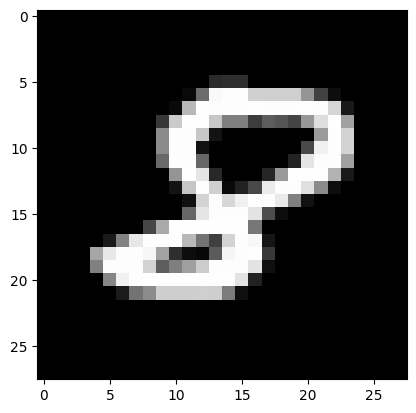

Predicted: 8
Actual: 8


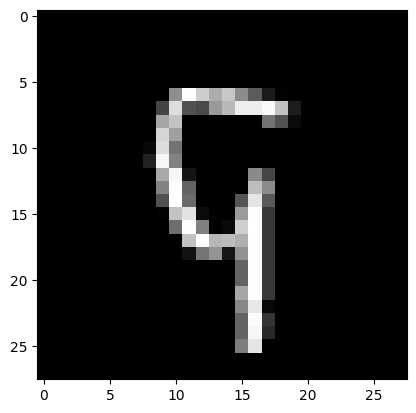

Predicted: 9
Actual: 9


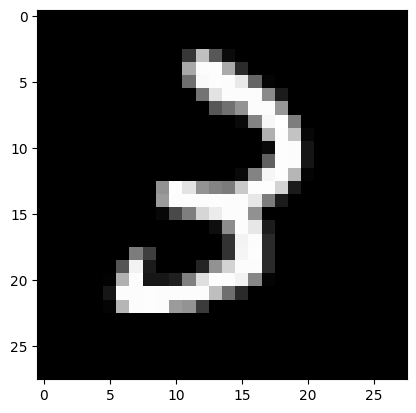

Predicted: 3
Actual: 3


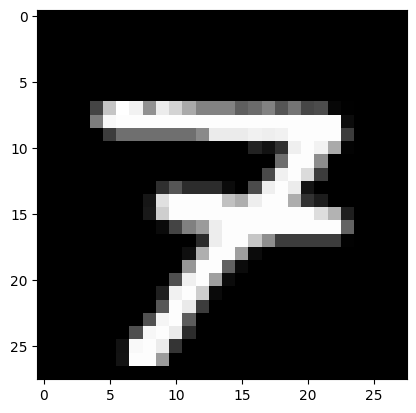

Predicted: 7
Actual: 7


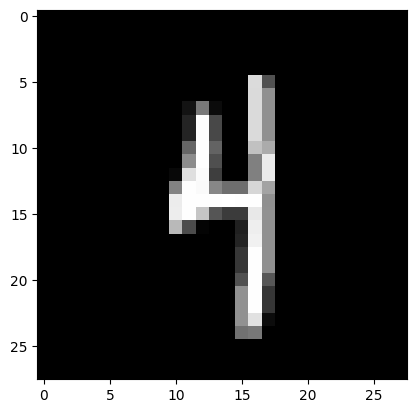

Predicted: 4
Actual: 4


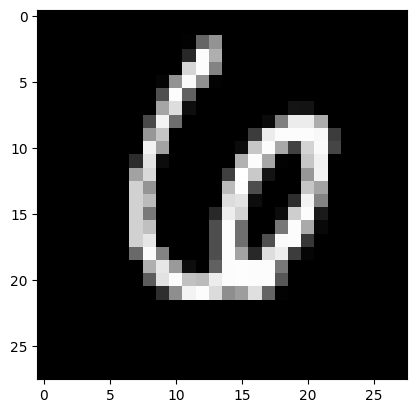

Predicted: 6
Actual: 6


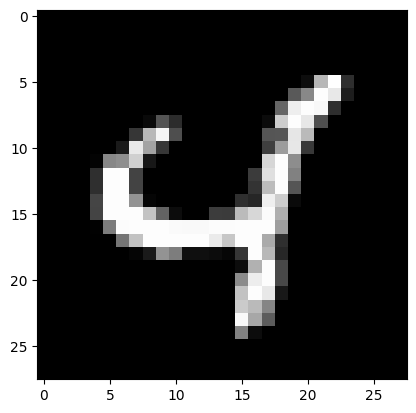

Predicted: 4
Actual: 4


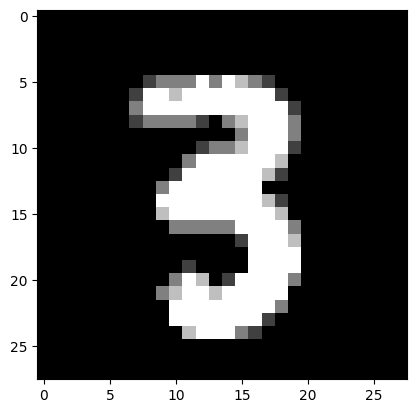

Predicted: 3
Actual: 3


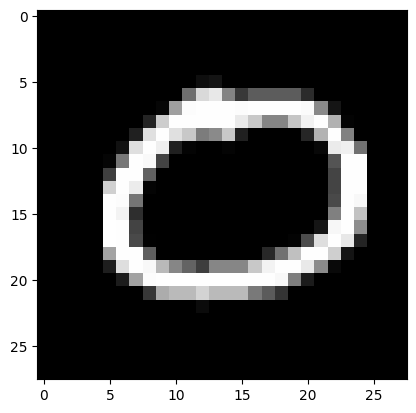

Predicted: 0
Actual: 0


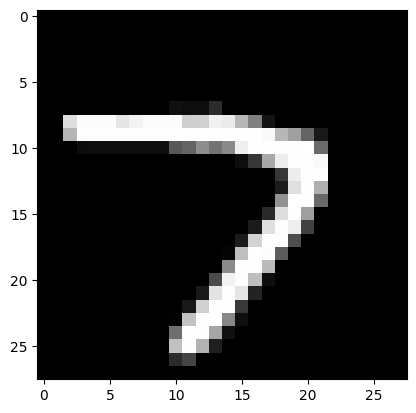

Predicted: 7
Actual: 7


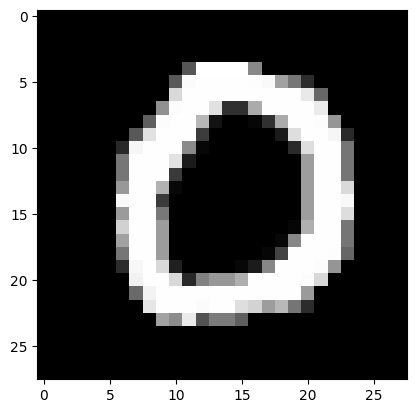

Predicted: 0
Actual: 0


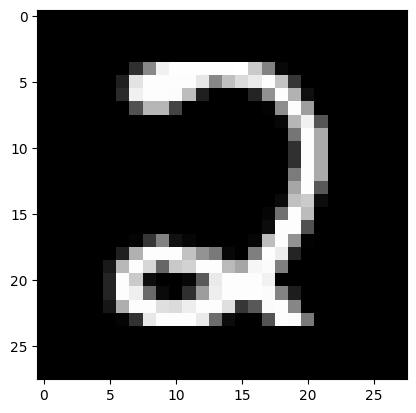

Predicted: 2
Actual: 2


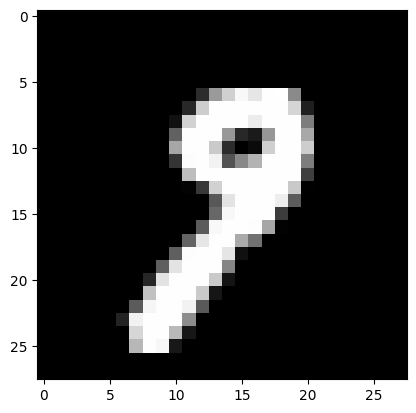

Predicted: 9
Actual: 9


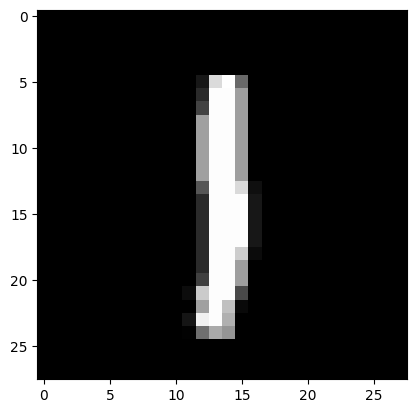

Predicted: 1
Actual: 1


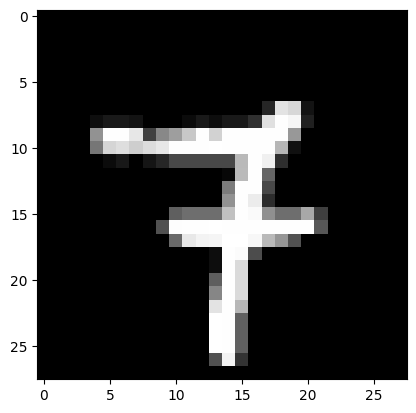

Predicted: 7
Actual: 7


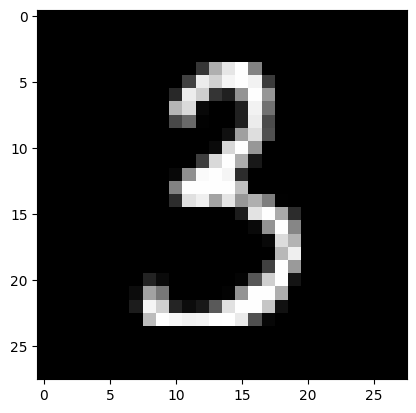

Predicted: 3
Actual: 3


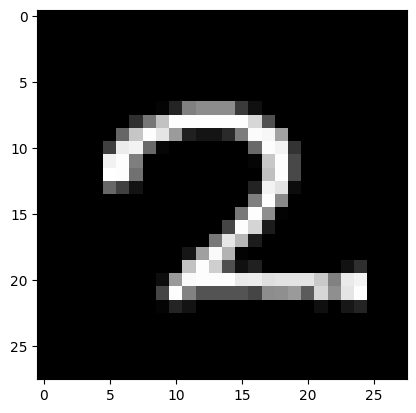

Predicted: 2
Actual: 2


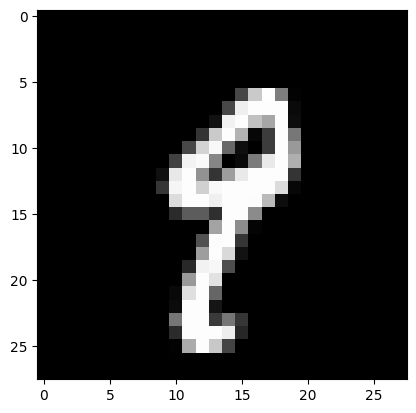

Predicted: 9
Actual: 9


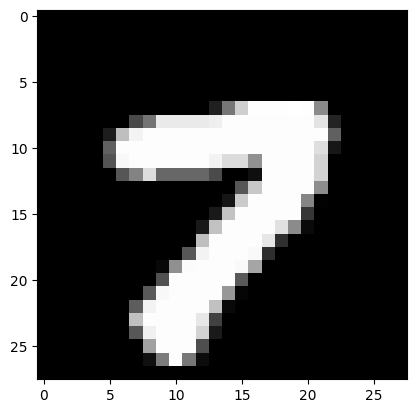

Predicted: 7
Actual: 7


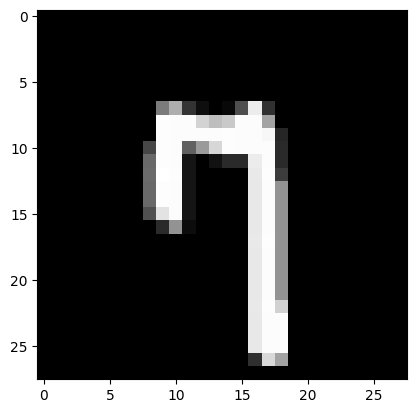

Predicted: 7
Actual: 7


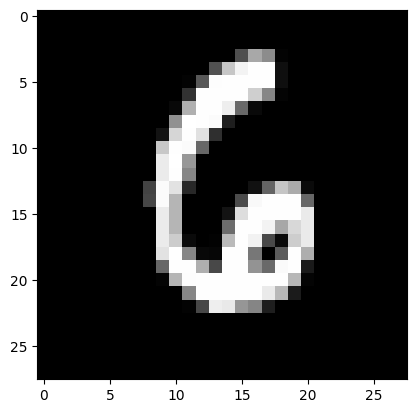

Predicted: 6
Actual: 6


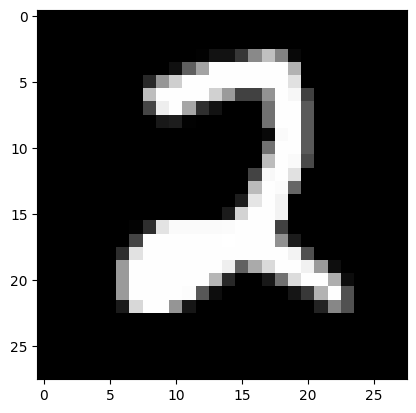

Predicted: 2
Actual: 2


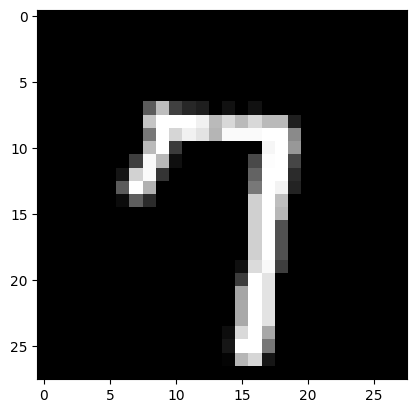

Predicted: 7
Actual: 7


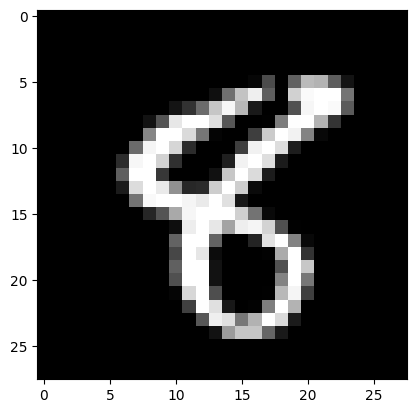

Predicted: 8
Actual: 8


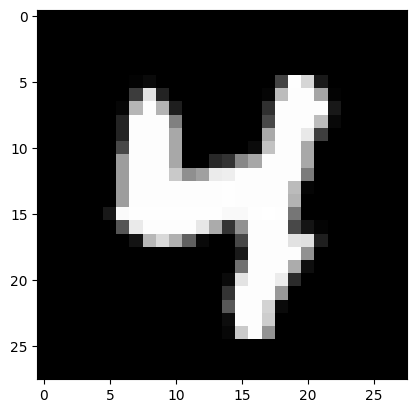

Predicted: 4
Actual: 4


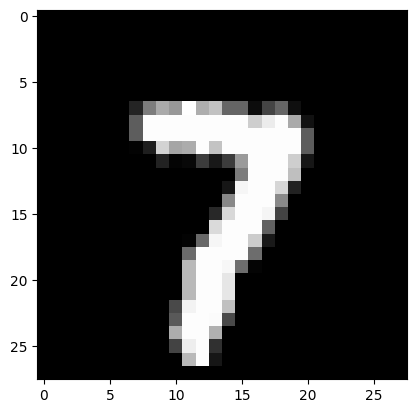

Predicted: 7
Actual: 7


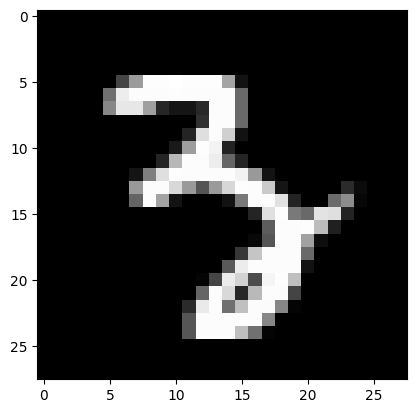

Predicted: 3
Actual: 3


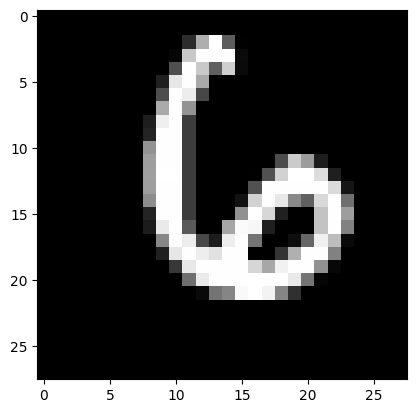

Predicted: 6
Actual: 6


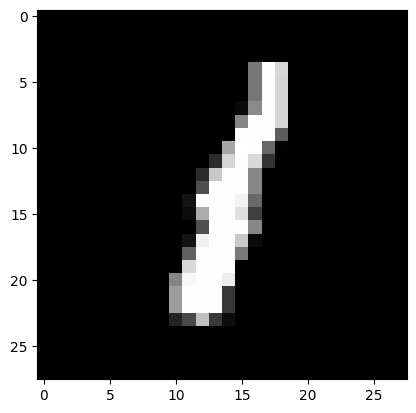

Predicted: 1
Actual: 1


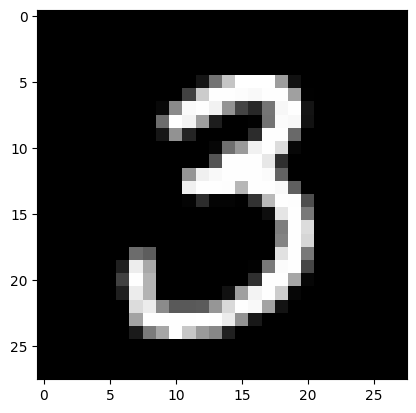

Predicted: 3
Actual: 3


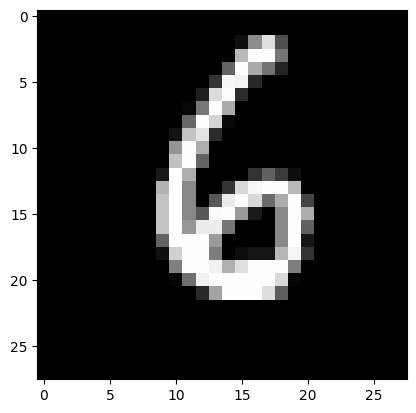

Predicted: 6
Actual: 6


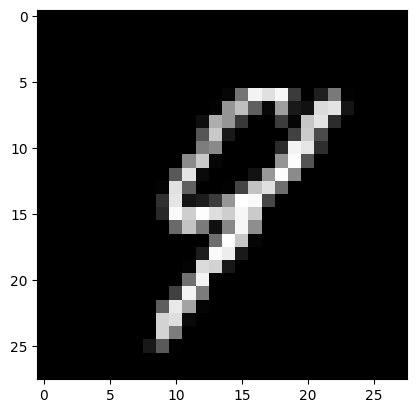

Predicted: 9
Actual: 9


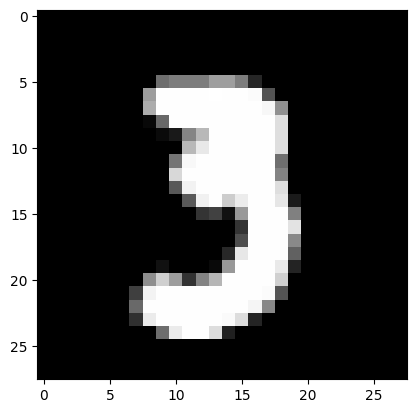

Predicted: 3
Actual: 3


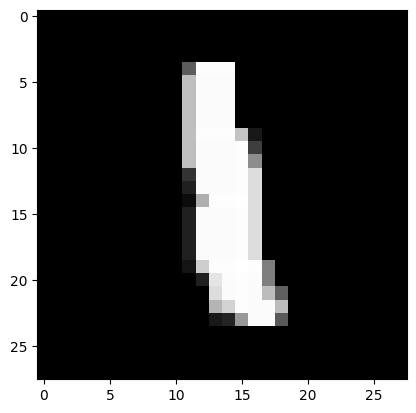

Predicted: 1
Actual: 1


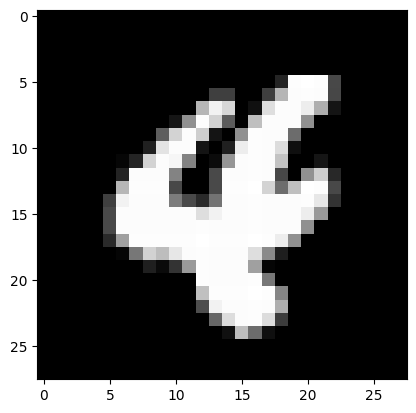

Predicted: 4
Actual: 4


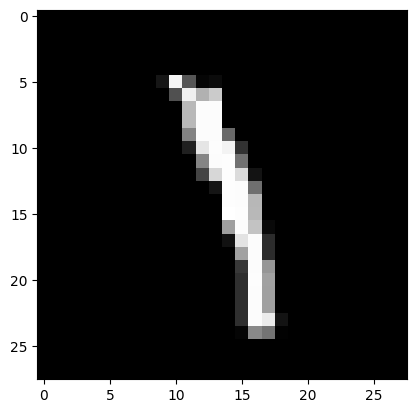

Predicted: 1
Actual: 1


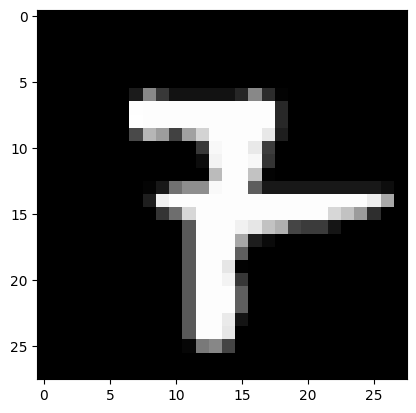

Predicted: 7
Actual: 7


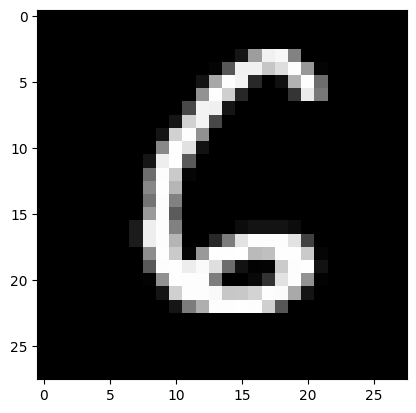

Predicted: 6
Actual: 6


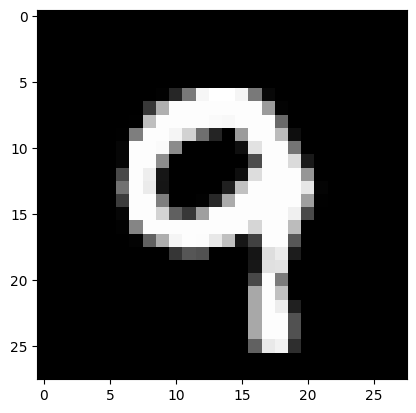

Predicted: 9
Actual: 9


In [55]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(100):
    
    plt.imshow(np_x_test_flat[i].reshape(28, 28), cmap="gray")
    plt.show()
    
    prediction = model.predict(np_x_test_flat[i:i+1], verbose=0)
    predicted = np.argmax(prediction)
    
    print("Predicted:", predicted)
    print("Actual:", int_y_test[i])